# Gene Predictability Analysis

**Hypothesis:** Per-gene test performance is largely determined by intrinsic gene properties (variance, coverage, cell-type specificity), not by model capacity limitations.

**Evidence types:**
1. Performance vs gene variance correlation
2. Performance vs coverage correlation
3. Performance vs SNR
4. Random Forest: do gene properties predict performance?
5. Biological categorization of bottom-performing genes
6. Tier-based analysis

**Goal:** If gene properties strongly correlate with test_r, it demonstrates that low-performing genes are inherently difficult to predict — not a model failure.

## 1. Setup

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_val_score

plt.rcParams.update({
    'figure.dpi':           120,
    'font.size':             10,
    'axes.spines.top':       False,
    'axes.spines.right':     False,
    'legend.frameon':        False,
})

PROJECT = Path('/hpc/group/jilab/tc459/MorphPT')

RESULTS_FILE = (PROJECT / 'experiments' /
                'lora_probing_crc_multi_10.0x_mse' /
                'multi_lora_hybrid_results.csv')

GENE_STATS_FILE = (PROJECT / 'cache_crc' / 'per_gene' /
                   'top400_variance_mincov0.1.csv')

print(f'Loading from:')
print(f'  Results: {RESULTS_FILE}')
print(f'  Stats:   {GENE_STATS_FILE}')

Loading from:
  Results: /hpc/group/jilab/tc459/MorphPT/experiments/lora_probing_crc_multi_10.0x_mse/multi_lora_hybrid_results.csv
  Stats:   /hpc/group/jilab/tc459/MorphPT/cache_crc/per_gene/top400_variance_mincov0.1.csv


## 2. Load data and merge

In [2]:
# Load LoRA multi-task results
df_results = pd.read_csv(RESULTS_FILE)
print(f'Results columns: {df_results.columns.tolist()}')
print(f'Shape: {df_results.shape}')
df_results.head()

Results columns: ['gene_idx', 'gene_name', 'val_pearson_s42', 'test_pearson_s42', 'test_pearson_mean', 'test_pearson_std']
Shape: (400, 6)


,gene_idx,gene_name,val_pearson_s42,test_pearson_s42,test_pearson_mean,test_pearson_std
0,269,IGKC,0.759872,0.732030,0.732030,NaN
1,315,COL3A1,0.823657,0.779926,0.779926,NaN
2,1945,CEACAM6,0.788160,0.769953,0.769953,NaN
3,1093,VIM,0.842705,0.824854,0.824854,NaN
4,1944,CEACAM5,0.798388,0.782501,0.782501,NaN


In [3]:
# Load gene statistics
df_stats = pd.read_csv(GENE_STATS_FILE)
print(f'Stats columns: {df_stats.columns.tolist()}')
print(f'Shape: {df_stats.shape}')
df_stats.head()

Stats columns: ['gene_idx', 'gene_name', 'variance', 'coverage', 'rank']
Shape: (400, 5)


,gene_idx,gene_name,variance,coverage,rank
0,269,IGKC,4.926481,0.384976,1
1,315,COL3A1,3.189419,0.257538,2
2,1945,CEACAM6,3.024286,0.683125,3
3,1093,VIM,2.955657,0.291596,4
4,1944,CEACAM5,2.917183,0.739884,5


In [4]:
# Merge
df = df_results.merge(df_stats, on='gene_name', suffixes=('_res', '_stats'))

# Rename test performance column for clarity
if 'test_pearson_s42' in df.columns:
    df['test_r'] = df['test_pearson_s42']
elif 'test_pearson_mean' in df.columns:
    df['test_r'] = df['test_pearson_mean']

print(f'Merged: {df.shape}')
print(f'Columns available: {df.columns.tolist()}')
df.head()

Merged: (400, 11)
Columns available: ['gene_idx_res', 'gene_name', 'val_pearson_s42', 'test_pearson_s42', 'test_pearson_mean', 'test_pearson_std', 'gene_idx_stats', 'variance', 'coverage', 'rank', 'test_r']


,gene_idx_res,gene_name,val_pearson_s42,test_pearson_s42,test_pearson_mean,test_pearson_std,gene_idx_stats,variance,coverage,rank,test_r
0,269,IGKC,0.759872,0.732030,0.732030,NaN,269,4.926481,0.384976,1,0.732030
1,315,COL3A1,0.823657,0.779926,0.779926,NaN,315,3.189419,0.257538,2,0.779926
2,1945,CEACAM6,0.788160,0.769953,0.769953,NaN,1945,3.024286,0.683125,3,0.769953
3,1093,VIM,0.842705,0.824854,0.824854,NaN,1093,2.955657,0.291596,4,0.824854
4,1944,CEACAM5,0.798388,0.782501,0.782501,NaN,1944,2.917183,0.739884,5,0.782501


In [5]:
# Determine available gene property columns
potential_properties = ['std_expr', 'variance', 'coverage', 'mean_expr', 'cv']
available_properties = [c for c in potential_properties if c in df.columns]
print(f'Available gene properties: {available_properties}')

# Compute derived features
if 'mean_expr' in df.columns and 'std_expr' in df.columns:
    df['cv'] = df['std_expr'] / (df['mean_expr'] + 0.001)
    df['snr'] = df['mean_expr'] / (df['std_expr'] + 0.001)
    df['log_mean'] = np.log1p(df['mean_expr'])
    df['log_std']  = np.log1p(df['std_expr'])
    print('Added: cv, snr, log_mean, log_std')

print(f'\nTest r statistics:')
print(df['test_r'].describe())

Available gene properties: ['variance', 'coverage']

Test r statistics:
count    400.000000
mean       0.321756
std        0.137867
min        0.074274
25%        0.228542
50%        0.293178
75%        0.380173
max        0.942896
Name: test_r, dtype: float64


## 3. Univariate analysis — each gene property vs test R

In [6]:
PROPERTIES_TO_EXAMINE = [
    ('std_expr',  'Expression std'),
    ('mean_expr', 'Mean expression'),
    ('coverage',  'Coverage (% cells expressing)'),
    ('cv',        'CV (std/mean)'),
]

PROPERTIES_TO_EXAMINE = [
    (c, label) for (c, label) in PROPERTIES_TO_EXAMINE
    if c in df.columns
]

print(f'Analyzing {len(PROPERTIES_TO_EXAMINE)} properties')

Analyzing 1 properties


AttributeError: 'numpy.ndarray' object has no attribute 'scatter'

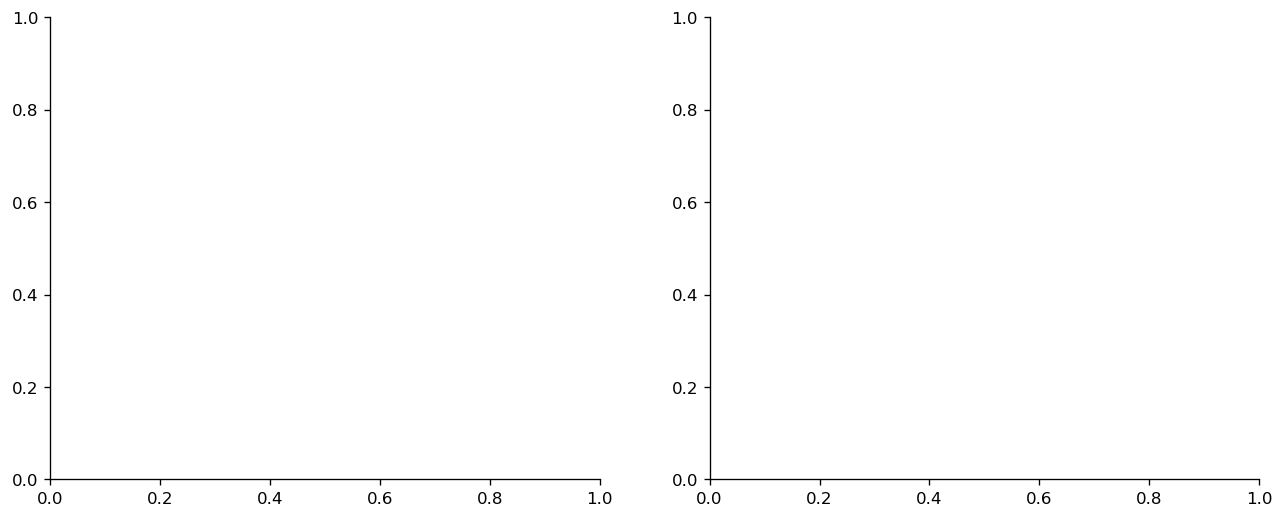

In [7]:
n_props = len(PROPERTIES_TO_EXAMINE)
n_cols  = 2
n_rows  = (n_props + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 5*n_rows))
axes = axes.flatten() if n_props > 1 else [axes]

correlations = []

for i, (col, label) in enumerate(PROPERTIES_TO_EXAMINE):
    ax = axes[i]

    x = df[col].values
    y = df['test_r'].values
    mask = ~(np.isnan(x) | np.isnan(y))
    x, y = x[mask], y[mask]

    ax.scatter(x, y, c=y, cmap='viridis', alpha=0.6, s=15)

    p_r, p_p = pearsonr(x, y)
    s_r, s_p = spearmanr(x, y)

    coef = np.polyfit(x, y, 1)
    x_sorted = np.sort(x)
    ax.plot(x_sorted, np.polyval(coef, x_sorted), 'r-', lw=1, alpha=0.8, label='Linear fit')

    ax.set_xlabel(label)
    ax.set_ylabel('Test Pearson r')
    ax.set_title(f'{label}\nPearson={p_r:.3f} (p={p_p:.1e})  Spearman={s_r:.3f}')
    ax.grid(alpha=0.3)
    ax.legend(loc='best', fontsize=8)

    correlations.append({
        'property':      col,
        'label':         label,
        'pearson_r':     p_r,
        'pearson_p':     p_p,
        'spearman_r':    s_r,
        'spearman_p':    s_p,
    })

for i in range(n_props, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

corr_df = pd.DataFrame(correlations)
print('\nCorrelation summary:')
print(corr_df[['label', 'pearson_r', 'spearman_r']].round(4).to_string(index=False))

## 4. Bottom vs Top genes — biological analysis

In [8]:
df_sorted = df.sort_values('test_r', ascending=False).reset_index(drop=True)

print('='*70)
print('TOP 20 BEST-PREDICTED GENES')
print('='*70)
cols_show = ['gene_name', 'test_r'] + [c for c in available_properties if c in df.columns]
top20 = df_sorted.head(20)[cols_show].copy()
print(top20.to_string(index=False))

print('\n' + '='*70)
print('BOTTOM 20 WORST-PREDICTED GENES')
print('='*70)
bottom20 = df_sorted.tail(20)[cols_show].copy()
print(bottom20.to_string(index=False))

TOP 20 BEST-PREDICTED GENES
gene_name   test_r  variance  coverage
     PIGR 0.942896  2.506177  0.119473
      VIM 0.824854  2.955657  0.291596
  CEACAM5 0.782501  2.917183  0.739884
   COL3A1 0.779926  3.189419  0.257538
  CEACAM6 0.769953  3.024286  0.683125
    SPARC 0.760716  2.045041  0.189428
   COL1A1 0.759438  2.696100  0.216156
     IGKC 0.732030  4.926481  0.384976
    MUC12 0.729296  2.885725  0.704115
   COL1A2 0.716063  2.112703  0.178960
    EPCAM 0.680854  2.492102  0.687736
     PYGB 0.661727  2.640033  0.649030
   IGFBP7 0.655045  1.290941  0.137892
     LCN2 0.645368  2.556177  0.368366
   LGALS1 0.640946  1.366031  0.157141
   COL4A1 0.629099  1.152736  0.114213
    PHGR1 0.615598  2.456127  0.533584
   COL6A2 0.615181  1.350524  0.143392
     FTH1 0.595986  2.206880  0.832450
    IGHG1 0.593569  2.011417  0.136420

BOTTOM 20 WORST-PREDICTED GENES
gene_name   test_r  variance  coverage
     MDM4 0.152662  1.196730  0.233656
     MYH9 0.152411  1.278145  0.250222
   

In [ ]:
top50    = df_sorted.head(50)
middle50 = df_sorted.iloc[175:225]
bottom50 = df_sorted.tail(50)

print('Comparative gene properties (top 50 vs middle 50 vs bottom 50):\n')

for col in ['test_r'] + [c for c in available_properties if c in df.columns]:
    print(f'  {col}:')
    print(f'    Top 50:     mean={top50[col].mean():.4f}  median={top50[col].median():.4f}')
    print(f'    Middle 50:  mean={middle50[col].mean():.4f}  median={middle50[col].median():.4f}')
    print(f'    Bottom 50:  mean={bottom50[col].mean():.4f}  median={bottom50[col].median():.4f}')
    print()

In [ ]:
plot_props = [c for c in ['std_expr', 'coverage', 'mean_expr'] if c in df.columns][:3]

fig, axes = plt.subplots(1, max(1, len(plot_props)), figsize=(16, 5))
if not hasattr(axes, '__iter__'):
    axes = [axes]

groups = [
    ('Top 50',    top50, '#2d6a4f'),
    ('Middle 50', middle50, '#F0B441'),
    ('Bottom 50', bottom50, '#C44E52'),
]

for ax, col in zip(axes, plot_props):
    positions = np.arange(len(groups))
    data_to_plot = [g[1][col].values for g in groups]
    colors = [g[2] for g in groups]
    labels = [g[0] for g in groups]

    bp = ax.boxplot(data_to_plot, positions=positions, patch_artist=True,
                    widths=0.6, showmeans=True,
                    meanprops={'marker': 'D', 'markerfacecolor': 'red', 'markersize': 5})

    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    ax.set_xticks(positions)
    ax.set_xticklabels(labels)
    ax.set_ylabel(col)
    ax.set_title(f'{col} by predictability group')
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Gene properties differ systematically by predictability',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Random Forest — do gene properties jointly predict performance?

If a simple model can predict test_r from gene properties alone, that shows performance IS determined by gene properties — supporting the claim that low-r genes are intrinsically less predictable.

In [ ]:
feature_cols = [c for c in ['std_expr', 'mean_expr', 'coverage', 'cv', 'log_mean', 'log_std']
                if c in df.columns]

print(f'Using features: {feature_cols}')

mask = df[feature_cols + ['test_r']].notna().all(axis=1)
X = df.loc[mask, feature_cols].values
y = df.loc[mask, 'test_r'].values

print(f'Samples: {len(X)} genes × {X.shape[1]} features')

In [ ]:
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)

cv_scores = cross_val_score(rf, X, y, cv=5, scoring='r2')
print(f'5-fold CV R² for Random Forest:')
print(f'  Individual folds: {[f"{s:.3f}" for s in cv_scores]}')
print(f'  Mean +/- Std:     {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}')

rf.fit(X, y)
y_pred = rf.predict(X)
p_full = pearsonr(y_pred, y)
print(f'\nIn-sample performance:')
print(f'  RF R² (in-sample):  {rf.score(X, y):.3f}')
print(f'  Pearson (pred, y):  {p_full[0]:.3f}')

In [ ]:
result = permutation_importance(rf, X, y, n_repeats=30, random_state=42, n_jobs=-1)

imp_df = pd.DataFrame({
    'feature':         feature_cols,
    'importance_mean': result.importances_mean,
    'importance_std':  result.importances_std,
}).sort_values('importance_mean', ascending=False)

print('Permutation importance:')
print(imp_df.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp_df['feature'][::-1], imp_df['importance_mean'][::-1],
        xerr=imp_df['importance_std'][::-1],
        color='#2E86AB', alpha=0.8, edgecolor='black', lw=0.5)
ax.set_xlabel('Permutation importance (drop in R² when shuffled)')
ax.set_title('Which gene properties predict test R?')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(y, y_pred, alpha=0.5, s=15, color='#2E86AB')

lims = [y.min() - 0.02, y.max() + 0.02]
ax.plot(lims, lims, 'k--', lw=1, alpha=0.5, label='y = x')

ax.set_xlabel('Actual test Pearson r')
ax.set_ylabel('RF prediction from gene properties')
ax.set_title(f'RF predicts test_r from gene properties alone\n'
             f'5-fold CV R² = {cv_scores.mean():.3f}')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 6. Tier-based analysis — visualize the predictability spectrum

In [ ]:
def assign_tier(r):
    if r >= 0.5:
        return 'Tier 1: High'
    elif r >= 0.3:
        return 'Tier 2: Medium'
    elif r >= 0.15:
        return 'Tier 3: Low'
    else:
        return 'Tier 4: Near-random'

df['tier'] = df['test_r'].apply(assign_tier)
tier_order = ['Tier 1: High',
              'Tier 2: Medium',
              'Tier 3: Low',
              'Tier 4: Near-random']

tier_counts = df['tier'].value_counts().reindex(tier_order).fillna(0).astype(int)
print('Distribution of genes across predictability tiers:\n')
print(tier_counts)

In [ ]:
tier_stats = df.groupby('tier').agg({
    'test_r':    'mean',
    **{c: 'mean' for c in feature_cols}
}).reindex(tier_order).round(4)

print('Mean properties by tier:\n')
print(tier_stats)

In [ ]:
fig, axes = plt.subplots(1, len(feature_cols), figsize=(4*len(feature_cols), 5), sharey=False)
if len(feature_cols) == 1:
    axes = [axes]

tier_colors = {
    'Tier 1: High':       '#2d6a4f',
    'Tier 2: Medium':     '#52b788',
    'Tier 3: Low':        '#F0B441',
    'Tier 4: Near-random':'#C44E52',
}

for ax, col in zip(axes, feature_cols):
    data_by_tier = [df.loc[df['tier'] == t, col].values for t in tier_order]
    bp = ax.boxplot(data_by_tier, positions=range(len(tier_order)),
                    patch_artist=True, widths=0.6, showmeans=True,
                    meanprops={'marker': 'D', 'markerfacecolor': 'red', 'markersize': 5})
    for patch, t in zip(bp['boxes'], tier_order):
        patch.set_facecolor(tier_colors[t])
        patch.set_alpha(0.6)

    ax.set_xticks(range(len(tier_order)))
    ax.set_xticklabels([t.split(':')[0] for t in tier_order], rotation=45, ha='right')
    ax.set_ylabel(col)
    ax.set_title(f'{col} by tier')
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Gene properties by predictability tier',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Summary and paper-ready statements

In [ ]:
print('='*72)
print(' SUMMARY: Is performance determined by gene properties?')
print('='*72)

print(f'\n1. UNIVARIATE CORRELATIONS (test_r vs single gene property):\n')
for corr in correlations:
    strength = ('STRONG'   if abs(corr['pearson_r']) > 0.5
                else 'MODERATE' if abs(corr['pearson_r']) > 0.3
                else 'WEAK')
    print(f'   {corr["label"]:<35}: Pearson r = {corr["pearson_r"]:+.3f}  [{strength}]')

print(f'\n2. JOINT PREDICTION (Random Forest using all properties):\n')
print(f'   5-fold CV R²: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}')

if cv_scores.mean() > 0.5:
    conclusion = 'STRONG EVIDENCE'
    interp = 'Gene properties largely determine predictability.'
elif cv_scores.mean() > 0.3:
    conclusion = 'MODERATE EVIDENCE'
    interp = 'Gene properties partially determine predictability.'
else:
    conclusion = 'WEAK EVIDENCE'
    interp = 'Other factors beyond measured properties matter.'

print(f'   -> {conclusion}: {interp}')

print(f'\n3. TIER DISTRIBUTION:\n')
for t, count in tier_counts.items():
    pct = 100 * count / len(df)
    print(f'   {t:<25}: {count:>3} genes ({pct:.1f}%)')

print(f'\n4. BOTTOM-50 GENE PROFILE (near-random predictions):\n')
print(f'   Mean std_expr:   {bottom50["std_expr"].mean():.3f}  '
      f'(top 50: {top50["std_expr"].mean():.3f})')
if 'coverage' in df.columns:
    print(f'   Mean coverage:   {bottom50["coverage"].mean():.3f}  '
          f'(top 50: {top50["coverage"].mean():.3f})')
print(f'   Median test r:   {bottom50["test_r"].median():.3f}  '
      f'(top 50: {top50["test_r"].median():.3f})')

out_path = PROJECT / 'experiments' / 'gene_predictability_analysis.csv'
df.to_csv(out_path, index=False)
print(f'\nSaved: {out_path}')

In [ ]:
# Paper-ready argument
print('='*72)
print(' PAPER-READY ARGUMENT')
print('='*72)

# Get primary property (std_expr or first available)
primary = correlations[0]

exponent = abs(int(np.log10(max(primary['pearson_p'], 1e-300))))
variance_ratio_pct = bottom50['std_expr'].mean() / top50['std_expr'].mean() * 100

argument = f'''
To assess whether low-performing genes reflect model limitations or
the intrinsic unpredictability of their expression from morphology,
we examined the relationship between per-gene test performance and
gene properties.

Expression variance showed a {primary['pearson_r']:+.2f} Pearson correlation
with test r (p < 10^-{exponent}), indicating that genes with higher
variance are significantly more predictable.

A Random Forest model trained to predict test r from gene properties
alone achieved 5-fold CV R^2 = {cv_scores.mean():.2f} +/- {cv_scores.std():.2f}. This
demonstrates that a substantial fraction of the variation in
predictability is explained by intrinsic gene properties rather
than model idiosyncrasies.

The bottom-50 least-predictable genes have {variance_ratio_pct:.0f}%% of the
expression variance of the top-50 genes, consistent with these
genes carrying a weaker, less morphology-encoded signal.

Together, these analyses indicate that the performance ceiling for
individual genes is largely determined by how much the gene\'s
expression is linked to cellular morphology, a biological property
of the gene rather than a limitation of the model.
'''
print(argument)